# Notebook 02 — MBS Cash Flows & Static Spread Analysis

## Fixed Income From Scratch

**Objective:** Project mortgage-backed security cash flows and compute the full hierarchy of spread measures.

### What We'll Build:
1. **MBS Cash Flow Engine** — Month-by-month projection of interest, principal, prepayment, default, loss
2. **Prepayment Conventions** — CPR, PSA, and their impact on cash flow profiles
3. **Weighted Average Life (WAL)** — The key metric for MBS relative value
4. **Spread Measures** — Nominal Spread, Z-Spread (to Treasury & Swap), Spread Duration
5. **Sensitivity Analysis** — How spreads and WAL change with prepayment speed

### The Core Insight:
For a Treasury bond, cash flows are known with certainty. For an MBS, they depend on **borrower behavior** — specifically, the rate at which homeowners prepay their mortgages. This uncertainty is the central analytical challenge of the entire MBS market. Every technique in this notebook and every module we build later (OAS, Monte Carlo, hedging) exists because of this single fact.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import sys, os

sys.path.insert(0, os.path.abspath('..'))
from utils.curves import (
    bootstrap_treasury_curve, bootstrap_swap_curve,
    sample_treasury_data, sample_swap_data, continuous_to_semi_annual
)
from utils.cashflows import (
    MBSPool, project_mbs_cashflows, mbs_yield, mbs_price_from_cashflows,
    treasury_cashflows
)
from utils.prepayment import (
    cpr_to_smm, smm_to_cpr, psa_to_cpr, psa_smm_vector,
    constant_smm_vector, speed_equivalents, hep_to_cpr, mhp_to_cpr
)
from utils.spreads import (
    nominal_spread, z_spread, z_spread_from_mbs, swap_spread, spread_table
)

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

# Build curves from Notebook 01
tenors, par_yields = sample_treasury_data()
tsy_curve = bootstrap_treasury_curve(tenors, par_yields)
dep_t, dep_r, swp_t, swp_r = sample_swap_data()
swap_curve = bootstrap_swap_curve(dep_t, dep_r, swp_t, swp_r)

print("Curves and modules loaded successfully.")

Curves and modules loaded successfully.


---
## 1. Anatomy of a Mortgage Pass-Through

A mortgage pass-through is the simplest MBS structure. A pool of residential mortgages is securitized, and investors receive a pro-rata share of the pool's cash flows (minus servicing/guarantee fees).

### Our Example Pool:
We'll model a **Fannie Mae 30-Year 6.0% pass-through** — one of the most liquid instruments in the fixed income universe.

| Characteristic | Value | Meaning |
|:---|:---|:---|
| WAC (Weighted Avg Coupon) | 6.50% | Average gross mortgage rate in the pool |
| Net Coupon (Pass-Through Rate) | 6.00% | Rate paid to investors (WAC minus fees) |
| Servicing/G-Fee | 0.50% | Goes to servicer (25bp) + Fannie Mae (25bp) |
| WAM (Weighted Avg Maturity) | 348 months | ~29 years remaining |
| WALA (Weighted Avg Loan Age) | 12 months | Pool is 1 year seasoned |
| Original Balance | $1,000,000 | Face amount at issuance |
| Current Balance | $988,000 | After 12 months of amortization |

In [5]:
# Define our MBS pool
pool = MBSPool(
    original_balance=1_000_000,
    current_balance=988_000,
    wac=0.065,           # 6.50% gross coupon
    net_coupon=0.060,     # 6.00% pass-through rate
    wam=348,              # 29 years remaining
    age=12,               # 1 year seasoned
    original_term=360     # 30-year original term
)

print("MBS Pool Characteristics")
print("=" * 40)
print(f"Original Balance:  ${pool.original_balance:>12,.0f}")
print(f"Current Balance:   ${pool.current_balance:>12,.0f}")
print(f"Pool Factor:       {pool.factor:>12.6f}")
print(f"WAC (Gross):       {pool.wac*100:>11.2f}%")
print(f"Net Coupon:        {pool.net_coupon*100:>11.2f}%")
print(f"Servicing Strip:   {pool.servicing_fee*100:>11.2f}%")
print(f"WAM:               {pool.wam:>9d} months")
print(f"WALA:              {pool.age:>9d} months")
print(f"Original Term:     {pool.original_term:>9d} months")

MBS Pool Characteristics
Original Balance:  $   1,000,000
Current Balance:   $     988,000
Pool Factor:           0.988000
WAC (Gross):              6.50%
Net Coupon:               6.00%
Servicing Strip:          0.50%
WAM:                     348 months
WALA:                     12 months
Original Term:           360 months


---
## 2. Prepayment Conventions Deep Dive

### Why Multiple Conventions Exist

Different asset classes have different prepayment behaviors, so each developed its own convention:

**CPR (Conditional Prepayment Rate):** The annualized fraction of the current outstanding balance that prepays. Convert to monthly SMM:

$$SMM = 1 - (1 - CPR)^{1/12}$$

**PSA (Public Securities Association):** The standard for agency MBS. Captures the **seasoning ramp** — new pools prepay slowly (borrowers just moved in), then ramp up:
- 100% PSA: CPR rises linearly from 0.2% at month 1 to 6.0% at month 30, then flat
- 200% PSA: double that (12% CPR plateau)
- 50% PSA: half (3% CPR plateau)

**HEP, ABS, MHP, PPC:** Conventions for home equity, auto, manufactured housing, and CMBS — each with different ramp shapes and peak levels reflecting the underlying borrower population.

The **critical distinction**: CPR is a fraction of CURRENT balance. ABS speed is a fraction of ORIGINAL balance. As the pool pays down, the same ABS speed implies accelerating SMM.

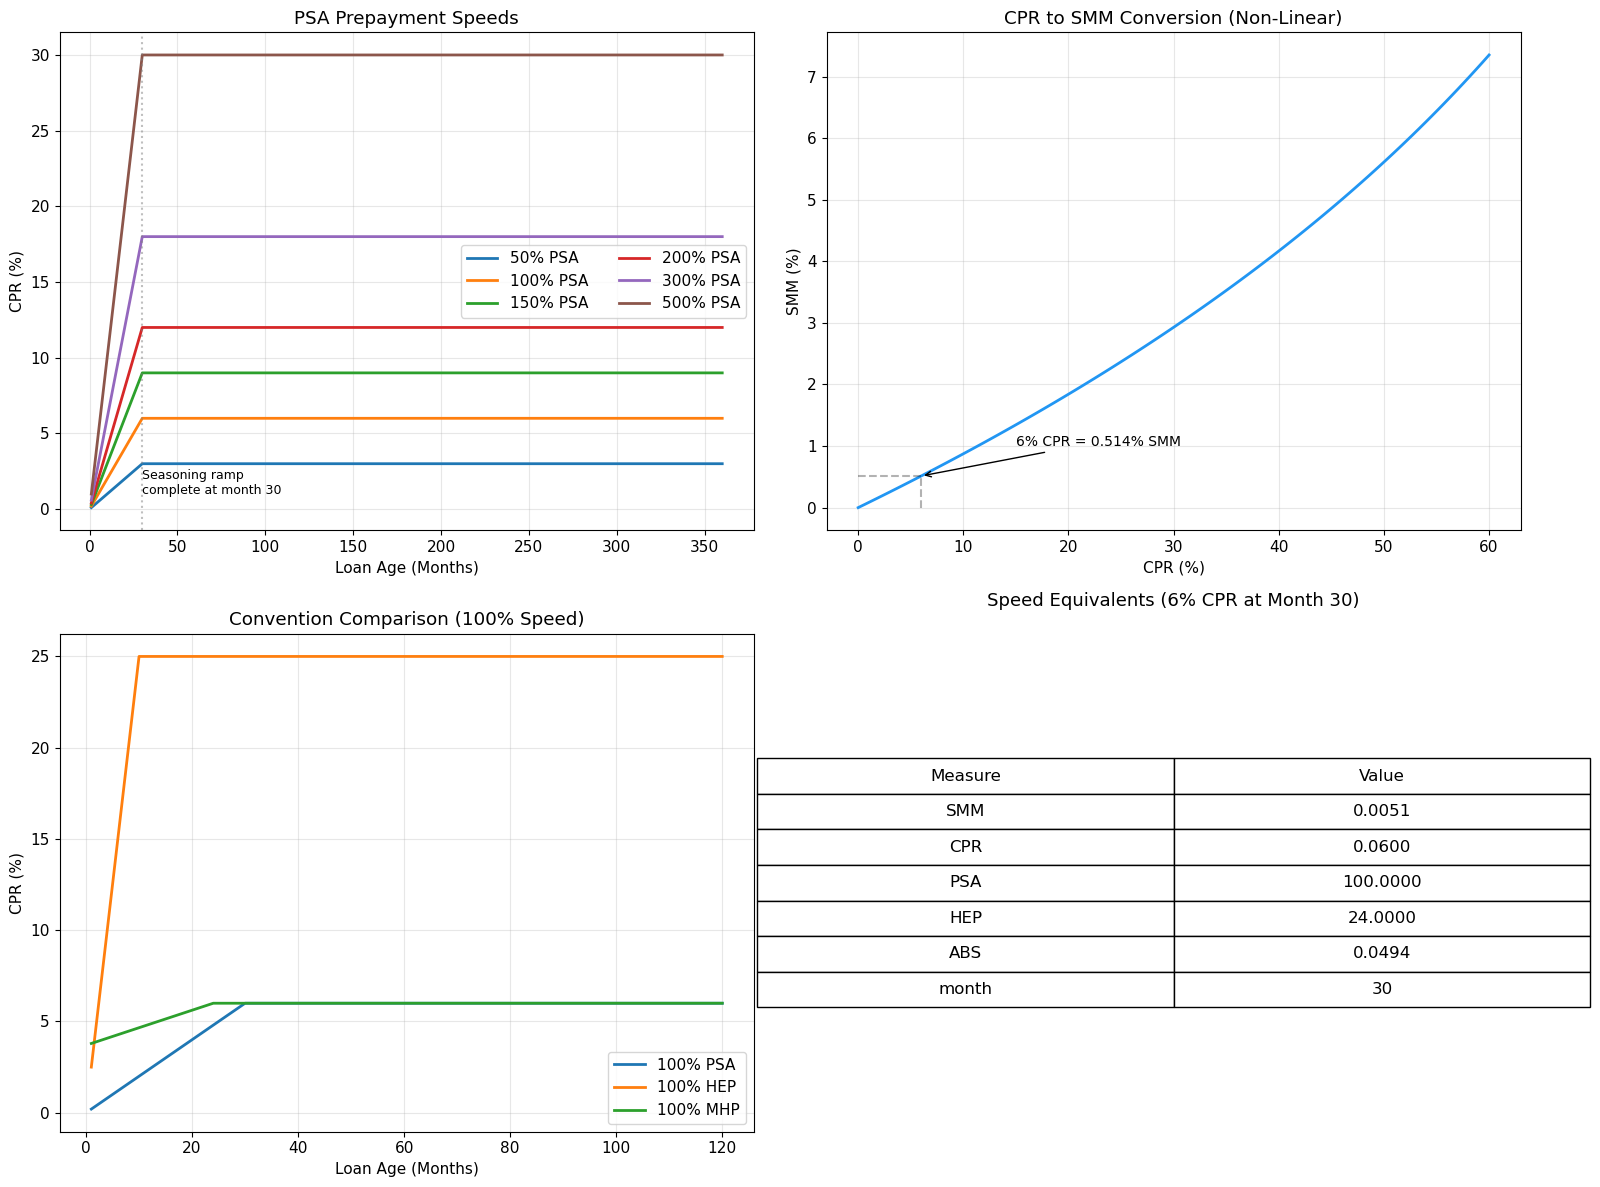

In [8]:
# Visualize prepayment conventions
months = np.arange(1, 361)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# PSA curves
ax = axes[0, 0]
for psa in [50, 100, 150, 200, 300, 500]:
    cprs = psa_to_cpr(psa, months) * 100
    ax.plot(months, cprs, label=f'{psa}% PSA', linewidth=2)
ax.set_xlabel('Loan Age (Months)')
ax.set_ylabel('CPR (%)')
ax.set_title('PSA Prepayment Speeds')
ax.legend(ncol=2)
ax.axvline(x=30, color='gray', linestyle=':', alpha=0.5)
ax.annotate('Seasoning ramp\ncomplete at month 30', xy=(30, 1), fontsize=9)

# CPR to SMM relationship
ax = axes[0, 1]
cprs = np.linspace(0, 0.60, 100)
smms = cpr_to_smm(cprs) * 100
ax.plot(cprs * 100, smms, linewidth=2, color='#2196F3')
ax.plot([6, 6], [0, cpr_to_smm(0.06)*100], 'k--', alpha=0.3)
ax.plot([0, 6], [cpr_to_smm(0.06)*100, cpr_to_smm(0.06)*100], 'k--', alpha=0.3)
ax.annotate(f'6% CPR = {cpr_to_smm(0.06)*100:.3f}% SMM', xy=(6, cpr_to_smm(0.06)*100),
            xytext=(15, 1), fontsize=10, arrowprops=dict(arrowstyle='->'))
ax.set_xlabel('CPR (%)')
ax.set_ylabel('SMM (%)')
ax.set_title('CPR to SMM Conversion (Non-Linear)')

# Compare conventions: PSA vs HEP vs MHP
ax = axes[1, 0]
ax.plot(months[:120], psa_to_cpr(100, months[:120]) * 100, label='100% PSA', linewidth=2)
ax.plot(months[:120], hep_to_cpr(100, months[:120]) * 100, label='100% HEP', linewidth=2)
ax.plot(months[:120], mhp_to_cpr(100, months[:120]) * 100, label='100% MHP', linewidth=2)
ax.set_xlabel('Loan Age (Months)')
ax.set_ylabel('CPR (%)')
ax.set_title('Convention Comparison (100% Speed)')
ax.legend()

# Speed equivalents table
ax = axes[1, 1]
ax.axis('off')
equivs = speed_equivalents(cpr_to_smm(0.06), month=30)
table_data = [[k, f"{v:.4f}" if isinstance(v, float) else str(v)] for k, v in equivs.items()]
table = ax.table(cellText=table_data, colLabels=['Measure', 'Value'],
                 loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.8)
ax.set_title('Speed Equivalents (6% CPR at Month 30)', fontsize=13, pad=20)

plt.tight_layout()
plt.show()

---
## 3. Cash Flow Projection

Now we project the full month-by-month cash flows. For each month:

1. **Scheduled Payment** = standard mortgage amortization formula
2. **Gross Interest** = Balance × WAC/12  
3. **Net Interest** = Balance × Net Coupon/12 (what the investor receives)
4. **Scheduled Principal** = Payment - Gross Interest
5. **Prepayment** = SMM × (Balance - Scheduled Principal)
6. **End Balance** = Balance - Scheduled Principal - Prepayment

We'll project under three scenarios to see how prepayment speed transforms the cash flow profile:

In [33]:
# Project cash flows at different speeds
scenarios = {
    '0% CPR (No Prepay)': project_mbs_cashflows(pool, cpr=0.0),
    '100% PSA': project_mbs_cashflows(pool, psa_speed=100),
    '150% PSA': project_mbs_cashflows(pool, psa_speed=150),
    '6% CPR (Constant)': project_mbs_cashflows(pool, cpr=0.06),
    '300% PSA': project_mbs_cashflows(pool, psa_speed=300),
    '15% CPR (Fast)': project_mbs_cashflows(pool, cpr=0.15),
}

# Summary table
print("Cash Flow Summary Across Prepayment Scenarios")
print("=" * 85)
print(f"{'Scenario':<22} {'WAL (Yrs)':>10} {'Total Int ($)':>15} {'Total Prin ($)':>15} {'Months':>8}")
print("-" * 85)
for name, cf in scenarios.items():
    active = cf.flows[cf.flows['beg_balance'] > 1].shape[0]
    print(f"{name:<22} {cf.weighted_avg_life:>10.2f} {cf.total_interest:>15,.0f} {cf.total_principal:>15,.0f} {active:>8}")

print()
wal_min = min(cf.weighted_avg_life for cf in scenarios.values())
wal_max = max(cf.weighted_avg_life for cf in scenarios.values())
print(f"KEY INSIGHT: WAL ranges from {wal_min:.1f} to {wal_max:.1f} years depending on prepay speed.")
print("This means the SAME security has fundamentally different risk characteristics")
print("under different prepayment assumptions. This is why OAS exists.")

Cash Flow Summary Across Prepayment Scenarios
Scenario                WAL (Yrs)   Total Int ($)  Total Prin ($)   Months
-------------------------------------------------------------------------------------
0% CPR (No Prepay)          18.84       1,116,708         988,000      348
100% PSA                    10.76         637,964         988,000      348
150% PSA                     8.56         507,265         988,000      348
6% CPR (Constant)           10.49         621,909         988,000      348
300% PSA                     5.04         298,653         988,000      348
15% CPR (Fast)               5.50         326,211         988,000      348

KEY INSIGHT: WAL ranges from 5.0 to 18.8 years depending on prepay speed.
This means the SAME security has fundamentally different risk characteristics
under different prepayment assumptions. This is why OAS exists.


In [13]:
# Detailed cash flow display for 150% PSA
cf_150 = scenarios['150% PSA']
print("Detailed Cash Flows — 150% PSA (first 24 months, then every 12th month)")
print("=" * 110)

# Show first 24 months
display_df = cf_150.flows.copy()
display_df['month_display'] = display_df['month'] + pool.age  # Absolute age

# Select rows to display
first_24 = display_df.head(24)
annual = display_df.iloc[23::12]
show = pd.concat([first_24, annual]).drop_duplicates()

cols = ['month', 'beg_balance', 'net_interest', 'scheduled_principal', 
        'prepayment', 'total_principal', 'total_cashflow', 'end_balance', 'cpr']
formatted = show[cols].copy()
formatted['cpr'] = formatted['cpr'] * 100
for c in ['beg_balance', 'net_interest', 'scheduled_principal', 'prepayment', 
          'total_principal', 'total_cashflow', 'end_balance']:
    formatted[c] = formatted[c].map(lambda x: f"{x:>12,.0f}")
formatted['cpr'] = formatted['cpr'].map(lambda x: f"{x:>6.2f}%")

print(formatted.head(36).to_string(index=False))

Detailed Cash Flows — 150% PSA (first 24 months, then every 12th month)
 month  beg_balance net_interest scheduled_principal   prepayment total_principal total_cashflow  end_balance     cpr
     1      988,000        4,940                 964        3,267           4,230          9,170      983,770   3.90%
     2      983,770        4,919                 966        3,508           4,474          9,392      979,296   4.20%
     3      979,296        4,896                 968        3,747           4,714          9,611      974,582   4.50%
     4      974,582        4,873                 969        3,983           4,952          9,825      969,630   4.80%
     5      969,630        4,848                 970        4,216           5,187         10,035      964,443   5.10%
     6      964,443        4,822                 971        4,447           5,418         10,240      959,025   5.40%
     7      959,025        4,795                 972        4,674           5,646         10,441      

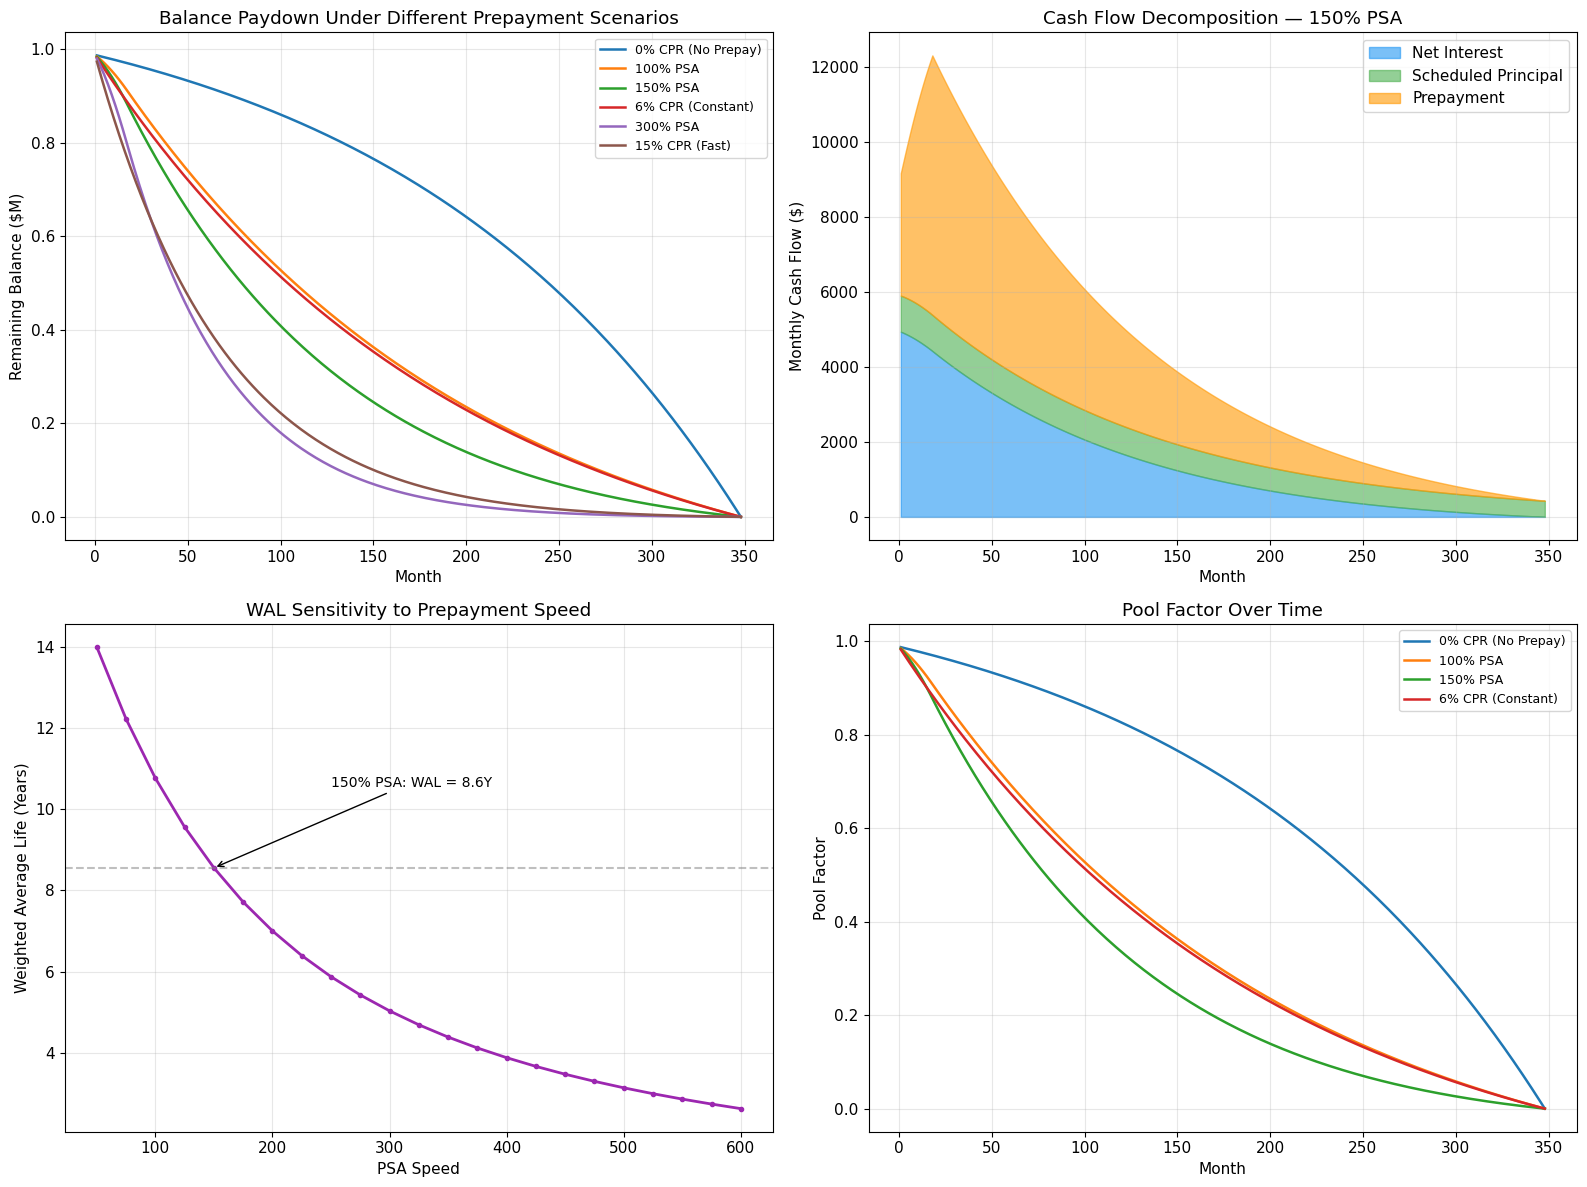

In [15]:
# Visualize cash flow profiles
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Balance paydown
ax = axes[0, 0]
for name, cf in scenarios.items():
    ax.plot(cf.flows['month'], cf.flows['end_balance'] / 1e6, label=name, linewidth=1.8)
ax.set_xlabel('Month')
ax.set_ylabel('Remaining Balance ($M)')
ax.set_title('Balance Paydown Under Different Prepayment Scenarios')
ax.legend(fontsize=9)

# Monthly cash flows (150% PSA breakdown)
ax = axes[0, 1]
cf = scenarios['150% PSA']
ax.fill_between(cf.flows['month'], 0, cf.flows['net_interest'], 
                alpha=0.6, label='Net Interest', color='#2196F3')
ax.fill_between(cf.flows['month'], cf.flows['net_interest'],
                cf.flows['net_interest'] + cf.flows['scheduled_principal'],
                alpha=0.6, label='Scheduled Principal', color='#4CAF50')
ax.fill_between(cf.flows['month'], 
                cf.flows['net_interest'] + cf.flows['scheduled_principal'],
                cf.flows['total_cashflow'],
                alpha=0.6, label='Prepayment', color='#FF9800')
ax.set_xlabel('Month')
ax.set_ylabel('Monthly Cash Flow ($)')
ax.set_title('Cash Flow Decomposition — 150% PSA')
ax.legend()

# WAL sensitivity
ax = axes[1, 0]
psa_range = np.arange(50, 601, 25)
wals = []
for psa in psa_range:
    cf_temp = project_mbs_cashflows(pool, psa_speed=psa)
    wals.append(cf_temp.weighted_avg_life)
ax.plot(psa_range, wals, 'o-', linewidth=2, markersize=3, color='#9C27B0')
ax.set_xlabel('PSA Speed')
ax.set_ylabel('Weighted Average Life (Years)')
ax.set_title('WAL Sensitivity to Prepayment Speed')
ax.axhline(y=scenarios['150% PSA'].weighted_avg_life, color='gray', linestyle='--', alpha=0.5)
ax.annotate(f'150% PSA: WAL = {scenarios["150% PSA"].weighted_avg_life:.1f}Y',
            xy=(150, scenarios['150% PSA'].weighted_avg_life), fontsize=10,
            xytext=(250, scenarios['150% PSA'].weighted_avg_life + 2),
            arrowprops=dict(arrowstyle='->'))

# Factor path
ax = axes[1, 1]
for name, cf in list(scenarios.items())[:4]:
    ax.plot(cf.flows['month'], cf.flows['factor'], label=name, linewidth=1.8)
ax.set_xlabel('Month')
ax.set_ylabel('Pool Factor')
ax.set_title('Pool Factor Over Time')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 4. Default & Loss Analysis

For non-agency MBS (subprime, alt-A) and ABS, default risk is a critical component. We model it with:

- **CDR (Constant Default Rate)**: Annual rate at which loans default
- **Severity**: Loss given default (1 - recovery rate). Typical: 35-45% for residential
- **Recovery Lag**: Months between default and loss realization (foreclosure timeline)

Defaults and prepayments are **competing risks** — a defaulted loan can't also prepay. Together, they determine the actual cash flows investors receive.

Impact of Defaults on Cash Flows (150% PSA)
Scenario                            WAL  Total Interest Total Principal
--------------------------------------------------------------------------------
No Default                         8.56         507,265         988,000
2% CDR / 35% Severity              7.60         443,509         935,772
5% CDR / 45% Severity              6.45         369,240         846,252
10% CDR / 55% Severity (Stress)     5.89         325,379         675,120


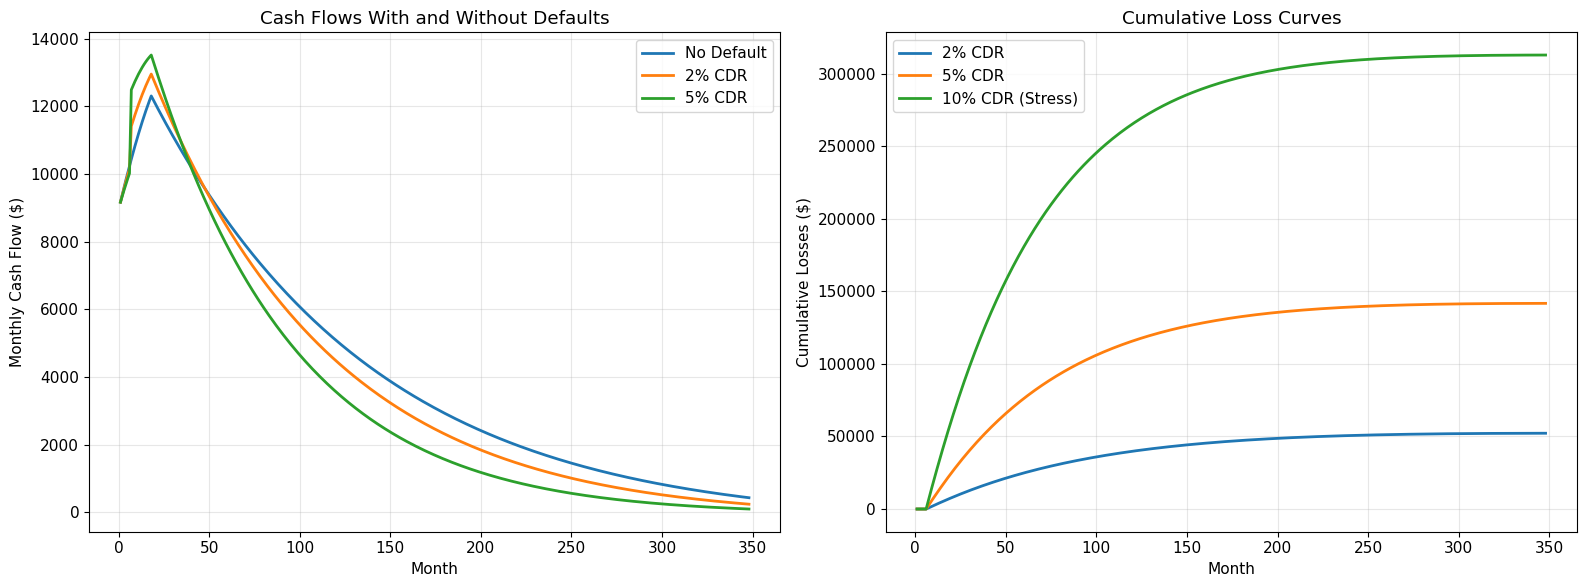

In [18]:
# Project with defaults
cf_no_default = project_mbs_cashflows(pool, psa_speed=150, cdr=0.0)
cf_low_default = project_mbs_cashflows(pool, psa_speed=150, cdr=0.02, severity=0.35)
cf_high_default = project_mbs_cashflows(pool, psa_speed=150, cdr=0.05, severity=0.45)
cf_stress = project_mbs_cashflows(pool, psa_speed=100, cdr=0.10, severity=0.55)

print("Impact of Defaults on Cash Flows (150% PSA)")
print("=" * 80)
print(f"{'Scenario':<30} {'WAL':>8} {'Total Interest':>15} {'Total Principal':>15}")
print("-" * 80)
for name, cf in [('No Default', cf_no_default), 
                  ('2% CDR / 35% Severity', cf_low_default),
                  ('5% CDR / 45% Severity', cf_high_default),
                  ('10% CDR / 55% Severity (Stress)', cf_stress)]:
    print(f"{name:<30} {cf.weighted_avg_life:>8.2f} {cf.total_interest:>15,.0f} {cf.total_principal:>15,.0f}")

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(cf_no_default.flows['month'], cf_no_default.flows['total_cashflow'], label='No Default', linewidth=2)
ax1.plot(cf_low_default.flows['month'], cf_low_default.flows['total_cashflow'], label='2% CDR', linewidth=2)
ax1.plot(cf_high_default.flows['month'], cf_high_default.flows['total_cashflow'], label='5% CDR', linewidth=2)
ax1.set_xlabel('Month')
ax1.set_ylabel('Monthly Cash Flow ($)')
ax1.set_title('Cash Flows With and Without Defaults')
ax1.legend()

# Cumulative losses
ax2.plot(cf_low_default.flows['month'], cf_low_default.flows['loss'].cumsum(), label='2% CDR', linewidth=2)
ax2.plot(cf_high_default.flows['month'], cf_high_default.flows['loss'].cumsum(), label='5% CDR', linewidth=2)
ax2.plot(cf_stress.flows['month'], cf_stress.flows['loss'].cumsum(), label='10% CDR (Stress)', linewidth=2)
ax2.set_xlabel('Month')
ax2.set_ylabel('Cumulative Losses ($)')
ax2.set_title('Cumulative Loss Curves')
ax2.legend()

plt.tight_layout()
plt.show()

---
## 5. Spread Measures — From Simple to Sophisticated

### The Spread Hierarchy (simplest to most rigorous):

**1. Nominal Spread:**
$$S_{nom} = y_{MBS} - y_{Treasury}(WAL)$$
Simplistic: uses one curve point, ignores cash flow timing.

**2. Z-Spread (Zero-Volatility Spread):**
$$Price = \\sum_{i} CF_i \\times e^{-(r(t_i) + Z) \\cdot t_i}$$
Constant spread to the ENTIRE zero curve that prices all cash flows correctly. Better than nominal, but still uses a single prepayment scenario.

**3. OAS (Option-Adjusted Spread):**
Same concept as Z-spread, but averaged across all Monte Carlo paths — properly accounting for the prepayment option. *Built in Notebook 07.*

**The relationship:** Z-Spread = OAS + Option Cost

For a Treasury (no embedded option), Z-Spread ≈ OAS ≈ 0. For a premium MBS (option cost > 0), OAS < Z-Spread.

In [21]:
# Calculate spreads for our MBS at different prices and speeds
print("Spread Analysis — FNMA 6.0% at Various Prices (150% PSA)")
print("=" * 80)

cf_base = project_mbs_cashflows(pool, psa_speed=150)
times = cf_base.flows['month'].values / 12.0
cashflows = cf_base.flows['total_cashflow'].values
mask = cashflows > 0
times_nz = times[mask]
cf_nz = cashflows[mask]
face = pool.current_balance

bond_yield_base = mbs_yield(cf_base, 99.0)

prices = [95.0, 97.0, 99.0, 100.0, 101.0, 103.0, 105.0]
print(f"{'Price':>8} {'Z-Sprd Tsy':>12} {'Z-Sprd Swap':>12} {'Nom Sprd':>12} {'Sprd Dur':>10}")
print("-" * 60)

for price in prices:
    z_tsy = z_spread(price, times_nz, cf_nz, tsy_curve, face=face)
    z_swp = z_spread(price, times_nz, cf_nz, swap_curve, face=face)
    
    # Nominal spread requires yield
    bey = mbs_yield(cf_base, price)
    if not np.isnan(bey):
        nom = nominal_spread(bey, tsy_curve, cf_base.weighted_avg_life)
        nom_str = f"{nom * 10000:>10.1f}bp"
    else:
        nom_str = "N/A"
    
    z_tsy_str = f"{z_tsy * 10000:>10.1f}bp" if not np.isnan(z_tsy) else "N/A"
    z_swp_str = f"{z_swp * 10000:>10.1f}bp" if not np.isnan(z_swp) else "N/A"
    
    print(f"{price:>8.2f} {z_tsy_str:>12} {z_swp_str:>12} {nom_str:>12}")

Spread Analysis — FNMA 6.0% at Various Prices (150% PSA)
   Price   Z-Sprd Tsy  Z-Sprd Swap     Nom Sprd   Sprd Dur
------------------------------------------------------------
   95.00      262.4bp      258.9bp      281.3bp
   97.00      226.0bp      222.7bp      244.0bp
   99.00      190.9bp      187.8bp      208.2bp
  100.00      173.8bp      170.8bp      190.7bp
  101.00      157.0bp      154.1bp      173.6bp
  103.00      124.3bp      121.6bp      140.3bp
  105.00       92.7bp       90.2bp      108.2bp


In [23]:
# Critical analysis: How spreads change with prepayment speed
# This demonstrates WHY Z-spread is insufficient for MBS

print("\nZ-Spread Sensitivity to Prepayment Speed (Price = 101.0)")
print("=" * 65)
print(f"{'Speed':<18} {'WAL':>6} {'Z-Sprd Tsy':>12} {'Z-Sprd Swap':>12}")
print("-" * 65)

price = 101.0
speeds = [('50% PSA', 50), ('100% PSA', 100), ('150% PSA', 150), 
          ('200% PSA', 200), ('300% PSA', 300), ('6% CPR', None),
          ('10% CPR', None), ('20% CPR', None)]

z_spreads_list = []
wal_list = []

for label, psa in speeds:
    if psa is not None:
        cf = project_mbs_cashflows(pool, psa_speed=psa)
    else:
        cpr_val = float(label.split('%')[0]) / 100
        cf = project_mbs_cashflows(pool, cpr=cpr_val)
    
    t = cf.flows['month'].values / 12.0
    c = cf.flows['total_cashflow'].values
    m = c > 0
    
    z_t = z_spread(price, t[m], c[m], tsy_curve, face=pool.current_balance)
    z_s = z_spread(price, t[m], c[m], swap_curve, face=pool.current_balance)
    
    z_spreads_list.append(z_t * 10000 if not np.isnan(z_t) else 0)
    wal_list.append(cf.weighted_avg_life)
    
    z_t_str = f"{z_t * 10000:>10.1f}bp" if not np.isnan(z_t) else "N/A"
    z_s_str = f"{z_s * 10000:>10.1f}bp" if not np.isnan(z_s) else "N/A"
    print(f"{label:<18} {cf.weighted_avg_life:>6.1f} {z_t_str:>12} {z_s_str:>12}")

print()
print("CRITICAL OBSERVATION: The Z-spread changes dramatically with prepay speed.")
print("For a PREMIUM bond (price > par), faster prepays HURT (you lose the above-par")
print("coupon stream sooner), so the Z-spread RISES to compensate. For a discount bond,")
print("the opposite: faster prepays help (principal returned at par, above purchase price).")
print("\nThis speed-dependency is exactly why we need OAS — a spread that accounts for")
print("the probability-weighted average across all possible prepayment outcomes.")


Z-Spread Sensitivity to Prepayment Speed (Price = 101.0)
Speed                 WAL   Z-Sprd Tsy  Z-Sprd Swap
-----------------------------------------------------------------
50% PSA              14.0      152.6bp      155.6bp
100% PSA             10.8      155.3bp      155.1bp
150% PSA              8.6      157.0bp      154.1bp
200% PSA              7.0      157.7bp      152.7bp
300% PSA              5.0      156.2bp      148.1bp
6% CPR               10.5      154.8bp      154.6bp
10% CPR               7.6      156.3bp      152.6bp
20% CPR               4.2      151.4bp      142.5bp

CRITICAL OBSERVATION: The Z-spread changes dramatically with prepay speed.
For a PREMIUM bond (price > par), faster prepays HURT (you lose the above-par
coupon stream sooner), so the Z-spread RISES to compensate. For a discount bond,
the opposite: faster prepays help (principal returned at par, above purchase price).

This speed-dependency is exactly why we need OAS — a spread that accounts for
the proba

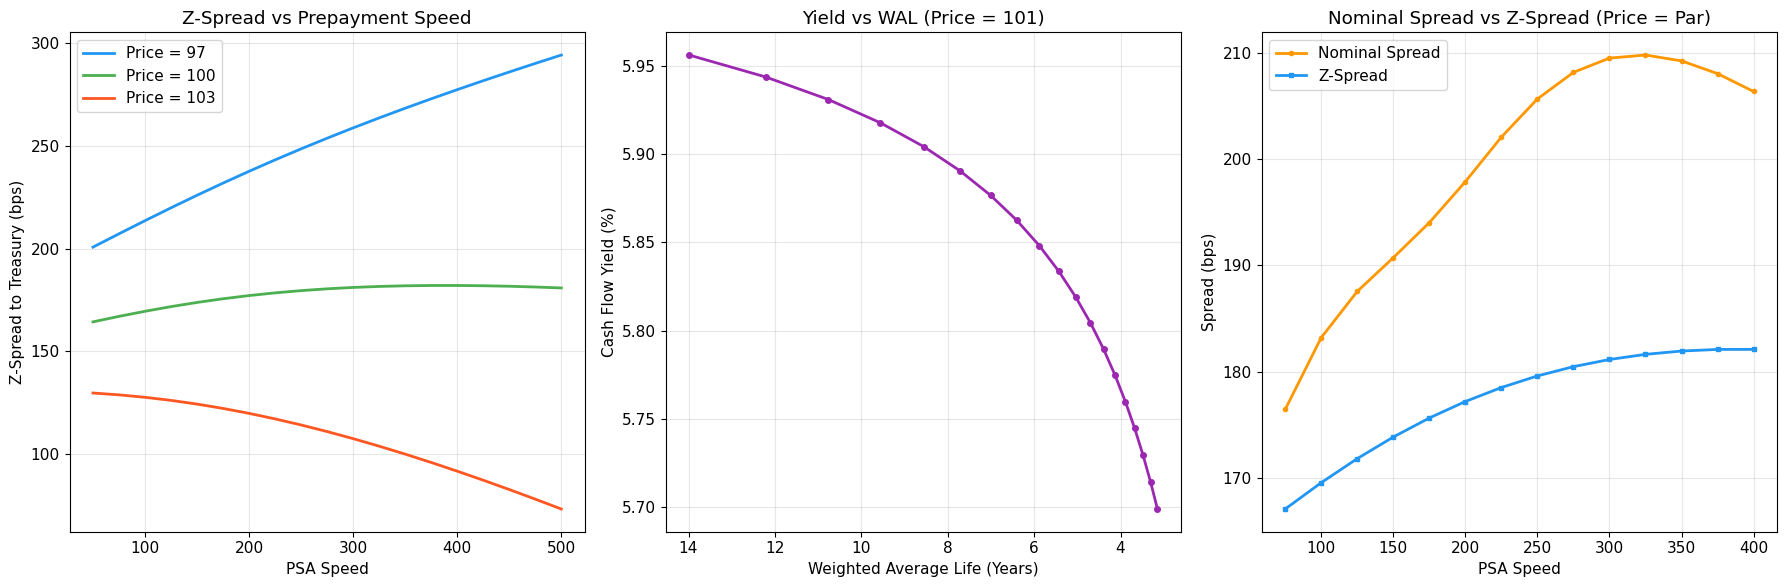

LEFT: Premium bonds see wider spreads with faster prepays (losing high coupon).
Discount bonds see tighter spreads (getting principal back above purchase price).
RIGHT: Nominal and Z-spread diverge when the curve is steep/inverted — Z-spread
is the more accurate measure because it uses the entire term structure.


In [25]:
# Visualize spread sensitivity
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Z-spread vs PSA (multiple prices)
ax = axes[0]
psa_range = np.arange(50, 501, 25)
for price, color in [(97, '#2196F3'), (100, '#4CAF50'), (103, '#FF5722')]:
    z_list = []
    for psa in psa_range:
        cf = project_mbs_cashflows(pool, psa_speed=psa)
        t = cf.flows['month'].values / 12.0
        c = cf.flows['total_cashflow'].values
        m = c > 0
        z = z_spread(price, t[m], c[m], tsy_curve, face=pool.current_balance)
        z_list.append(z * 10000 if not np.isnan(z) else np.nan)
    ax.plot(psa_range, z_list, '-', label=f'Price = {price}', linewidth=2, color=color)
ax.set_xlabel('PSA Speed')
ax.set_ylabel('Z-Spread to Treasury (bps)')
ax.set_title('Z-Spread vs Prepayment Speed')
ax.legend()

# WAL vs Price/Yield relationship
ax = axes[1]
psa_range2 = np.arange(50, 501, 25)
wals2 = []
yields2 = []
for psa in psa_range2:
    cf = project_mbs_cashflows(pool, psa_speed=psa)
    wals2.append(cf.weighted_avg_life)
    y = mbs_yield(cf, 101.0)
    yields2.append(y * 100 if not np.isnan(y) else np.nan)
ax.plot(wals2, yields2, 'o-', markersize=4, linewidth=2, color='#9C27B0')
ax.set_xlabel('Weighted Average Life (Years)')
ax.set_ylabel('Cash Flow Yield (%)')
ax.set_title('Yield vs WAL (Price = 101)')
ax.invert_xaxis()

# Nominal vs Z-spread comparison
ax = axes[2]
psa_range3 = np.arange(75, 401, 25)
nom_list = []
z_list = []
for psa in psa_range3:
    cf = project_mbs_cashflows(pool, psa_speed=psa)
    t = cf.flows['month'].values / 12.0
    c = cf.flows['total_cashflow'].values
    m = c > 0
    z = z_spread(100.0, t[m], c[m], tsy_curve, face=pool.current_balance)
    z_list.append(z * 10000 if not np.isnan(z) else np.nan)
    y = mbs_yield(cf, 100.0)
    if not np.isnan(y):
        n = nominal_spread(y, tsy_curve, cf.weighted_avg_life) * 10000
    else:
        n = np.nan
    nom_list.append(n)

ax.plot(psa_range3, nom_list, 'o-', label='Nominal Spread', linewidth=2, markersize=3, color='#FF9800')
ax.plot(psa_range3, z_list, 's-', label='Z-Spread', linewidth=2, markersize=3, color='#2196F3')
ax.set_xlabel('PSA Speed')
ax.set_ylabel('Spread (bps)')
ax.set_title('Nominal Spread vs Z-Spread (Price = Par)')
ax.legend()

plt.tight_layout()
plt.show()

print("LEFT: Premium bonds see wider spreads with faster prepays (losing high coupon).")
print("Discount bonds see tighter spreads (getting principal back above purchase price).")
print("RIGHT: Nominal and Z-spread diverge when the curve is steep/inverted — Z-spread")
print("is the more accurate measure because it uses the entire term structure.")

---
## 6. Comprehensive Spread Report

Let's generate the full spread analysis that a portfolio manager would see — all measures in one view, comparable to what systems like Polypaths or Bloomberg produce.

In [28]:
# Full spread report
cf_base = project_mbs_cashflows(pool, psa_speed=150)
price = 101.0

times_yr = cf_base.flows['month'].values / 12.0
cfs = cf_base.flows['total_cashflow'].values
mask = cfs > 0
times_nz = times_yr[mask]
cf_nz = cfs[mask]
bey = mbs_yield(cf_base, price)

full_report = spread_table(
    price=price,
    cashflow_times=times_nz,
    cashflows=cf_nz,
    treasury_curve=tsy_curve,
    swap_curve=swap_curve,
    wal=cf_base.weighted_avg_life,
    bond_yield=bey,
    face=pool.current_balance
)

print("=" * 60)
print("  COMPREHENSIVE SPREAD REPORT")
print("  FNMA 6.0% Pass-Through | Price: 101.00 | 150% PSA")
print("=" * 60)
print(f"  Cash Flow Yield (BEY):         {bey*100:.3f}%")
print(f"  Weighted Average Life:         {cf_base.weighted_avg_life:.2f} years")
print("-" * 60)
for key, val in full_report.items():
    label = key.replace('_', ' ').title()
    if val is not None:
        if 'bps' in key:
            print(f"  {label:<35s} {val:>10.1f} bps")
        else:
            print(f"  {label:<35s} {val:>10.3f}")
    else:
        print(f"  {label:<35s} {'N/A':>10s}")
print("-" * 60)
if full_report.get('z_spread_treasury_bps') and full_report.get('z_spread_swap_bps'):
    option_cost_approx = full_report['z_spread_treasury_bps'] - full_report['z_spread_swap_bps']
    print(f"  {'Treasury-Swap Basis':35s} {full_report.get('swap_basis_bps', 0):>10.1f} bps")
print("=" * 60)
print()
print("NOTE: True OAS requires Monte Carlo simulation (Notebook 07).")
print("The Z-Spread here overstates the 'pure' spread compensation because")
print("it includes the cost of the prepayment option embedded in the MBS.")

  COMPREHENSIVE SPREAD REPORT
  FNMA 6.0% Pass-Through | Price: 101.00 | 150% PSA
  Cash Flow Yield (BEY):         5.904%
  Weighted Average Life:         8.56 years
------------------------------------------------------------
  Z Spread Treasury Bps                    157.0 bps
  Z Spread Swap Bps                        154.1 bps
  Swap Basis Bps                             2.9 bps
  Nominal Spread Tsy Bps                   173.6 bps
  Nominal Spread Swap Bps                  167.7 bps
  Spread Duration                          5.950
------------------------------------------------------------
  Treasury-Swap Basis                        2.9 bps

NOTE: True OAS requires Monte Carlo simulation (Notebook 07).
The Z-Spread here overstates the 'pure' spread compensation because
it includes the cost of the prepayment option embedded in the MBS.


---
## Summary & What's Next

### What We Built:
- **MBS Cash Flow Engine** projecting interest, principal, prepayment, default, and loss
- **All major prepayment conventions** — CPR, PSA, HEP, MHP, ABS with conversions
- **WAL calculation** and its sensitivity to prepayment speed
- **Complete spread toolkit** — Nominal Spread, Z-Spread (Treasury & Swap), Spread Duration
- **Key insight demonstrated**: Spread measures are fundamentally dependent on prepayment assumptions

### The Central Problem This Reveals:
The Z-spread for a premium MBS at 100% PSA is dramatically different from 300% PSA. Which is "right"? Neither — because both assume a single deterministic prepayment path. The correct answer requires:

1. **A prepayment model** that responds to interest rates (Notebook 03)
2. **An interest rate model** that generates realistic rate paths (Notebook 06)
3. **Monte Carlo simulation** that averages across all possible outcomes → **OAS** (Notebook 07)

### Next: Notebook 03
Building the multi-factor prepayment model: refinancing, turnover, burnout, and aging components, calibrated to actual Fannie Mae loan-level data.